In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import plotly.express as px
from wordcloud import WordCloud
from collections import Counter
from typing import List
import matplotlib.gridspec as gridspec
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize'] = (10,8)
pd.set_option('display.max_columns', None)


file_path = '/content/gdrive/MyDrive/US_flights.xlsx'  # Adjust if needed
df = pd.read_excel(file_path, sheet_name='Monthly')
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y %b', errors='coerce')

df.to_csv("cleaned_file.csv", index=False)

df.head()

,year_month,data
0,1980-12-01,78.2
1,1981-01-01,79.3
2,1981-02-01,79.8
3,1981-03-01,82.1
4,1981-04-01,83.3


Mean: 209.05
Variance: 4778.16


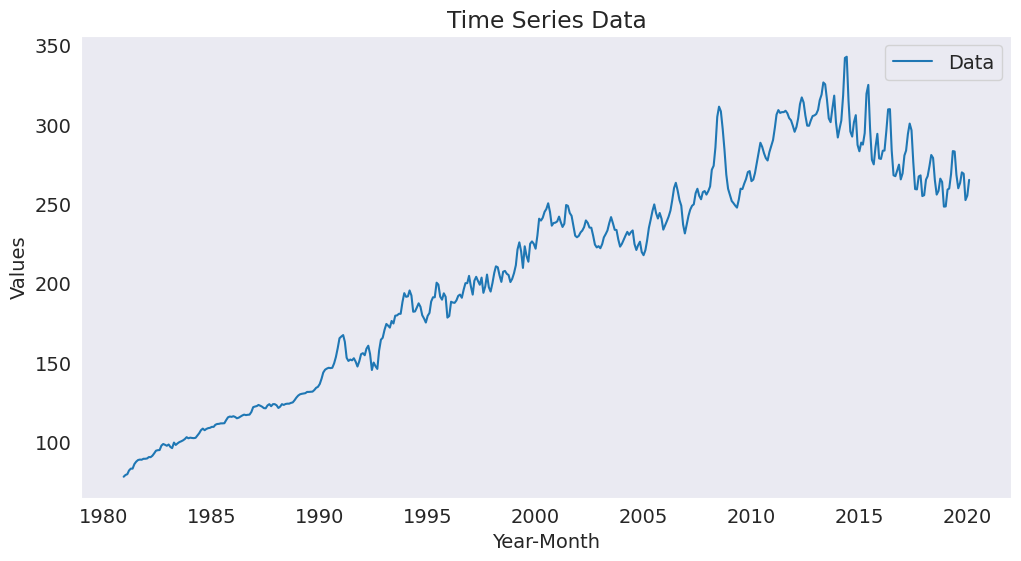

In [ ]:
#Printing the data for the Years
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("cleaned_file.csv", parse_dates=['year_month'])


df.set_index('year_month', inplace=True)

mean_value = df['data'].mean()
variance_value = df['data'].var()

print(f"Mean: {mean_value:.2f}")
print(f"Variance: {variance_value:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Data')
plt.xlabel("Year-Month")
plt.ylabel("Values")
plt.title("Time Series Data")
plt.legend()
plt.grid()
plt.show()


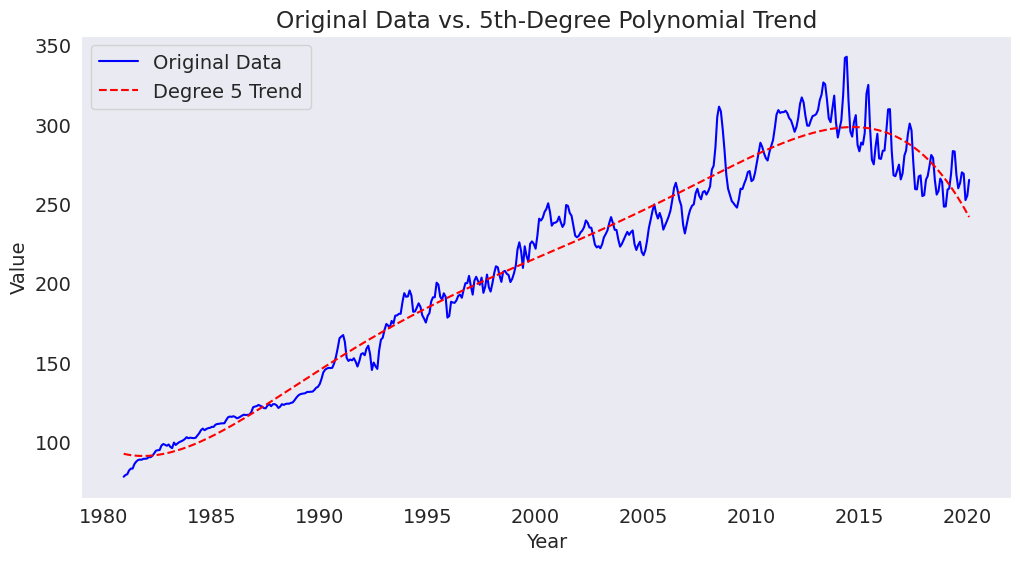

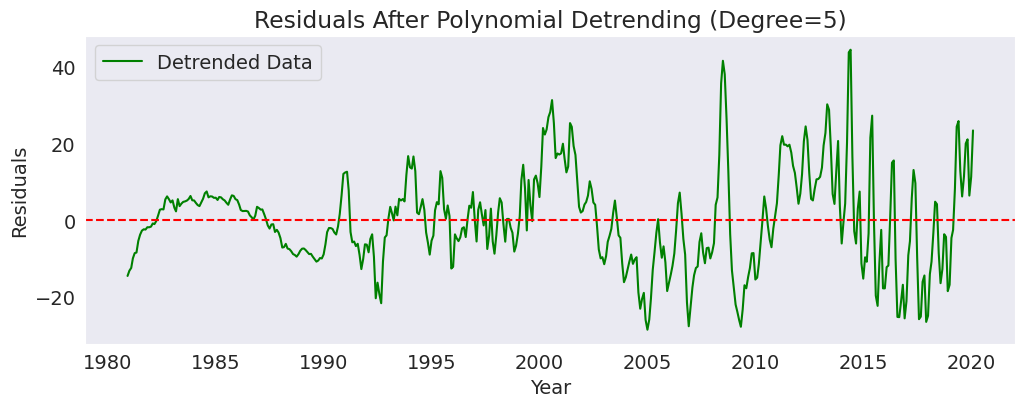

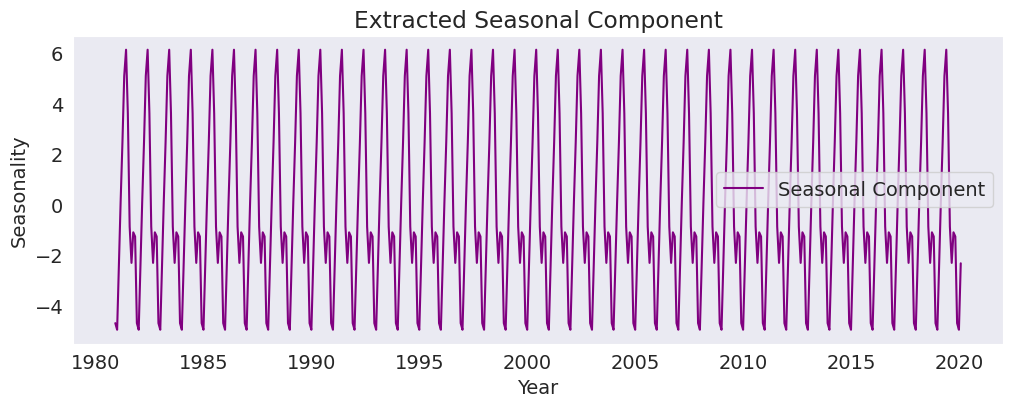

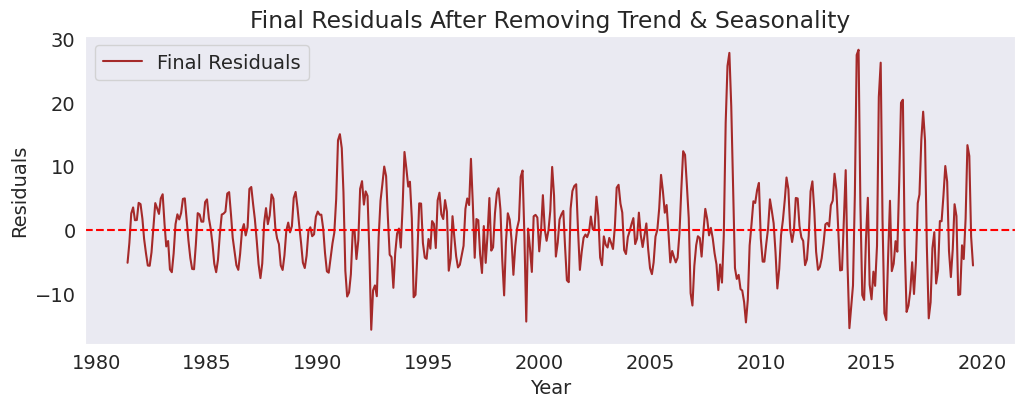

In [ ]:
# Detrending method is Polynomial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv("cleaned_file.csv", parse_dates=['year_month'])
df.set_index('year_month', inplace=True)

df = df.sort_index()


df['time_index'] = (df.index - df.index.min()).days / 30.44

degree = 5
coefficients = np.polyfit(df['time_index'], df['data'], degree)
polynomial = np.poly1d(coefficients)
df['trend'] = polynomial(df['time_index'])

df['detrended'] = df['data'] - df['trend']

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Original Data', color='blue')
plt.plot(df.index, df['trend'], label=f'Degree {degree} Trend', linestyle='--', color='red')
plt.title(f'Original Data vs. {degree}th-Degree Polynomial Trend')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(df.index, df['detrended'], label='Detrended Data', color='green')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Residuals After Polynomial Detrending (Degree={degree})')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()

decomposition = seasonal_decompose(df['data'], model='additive', period=12)


df['seasonal'] = decomposition.seasonal
df['residual'] = decomposition.resid

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['seasonal'], label='Seasonal Component', color='purple')
plt.title('Extracted Seasonal Component')
plt.xlabel('Year')
plt.ylabel('Seasonality')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['residual'], label='Final Residuals', color='brown')
plt.axhline(0, color='r', linestyle='--')
plt.title('Final Residuals After Removing Trend & Seasonality')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()




In [ ]:
# Stationarity Check
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = df['residual'].dropna()

adf_result = adfuller(residuals)
print("ADF Test:")
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical Values: {adf_result[4]}")
print("Conclusion:", "Stationary" if adf_result[1] < 0.05 else "Non-Stationary")

kpss_result = kpss(residuals, regression='c')
print("\nKPSS Test:")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Critical Values: {kpss_result[3]}")
print("Conclusion:", "Non-Stationary" if kpss_result[1] < 0.05 else "Stationary")


ADF Test:
  Test Statistic: -9.2083
  p-value: 0.0000
  Critical Values: {'1%': np.float64(-3.445299682487321), '5%': np.float64(-2.8681312035123967), '10%': np.float64(-2.570280872933884)}
Conclusion: Stationary

KPSS Test:
  Test Statistic: 0.0042
  p-value: 0.1000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: Stationary


<ipython-input-5-15a461f76f3f>:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(residuals, regression='c')


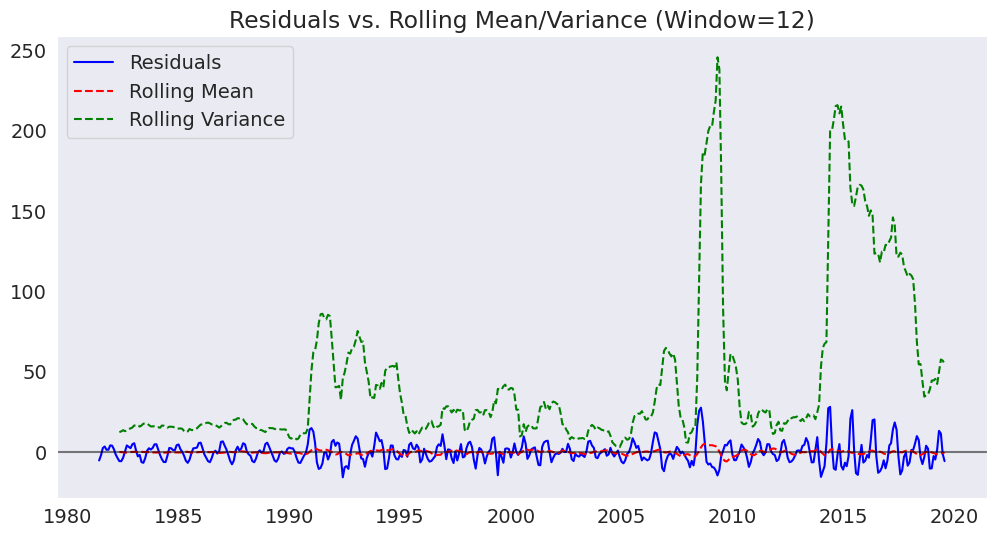

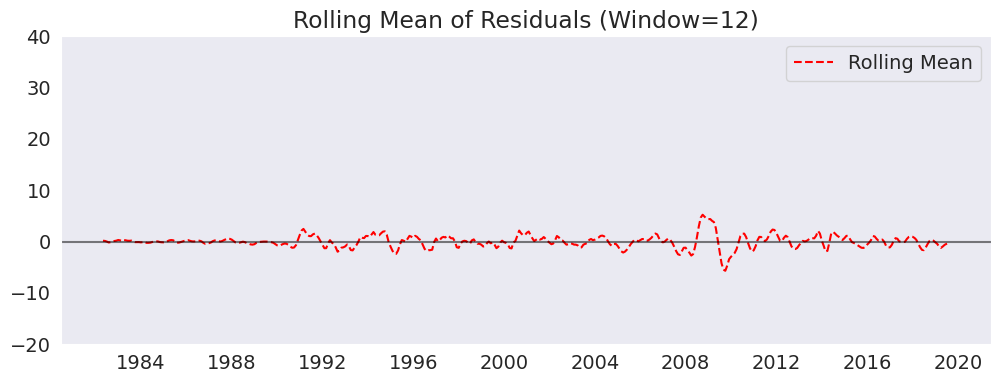

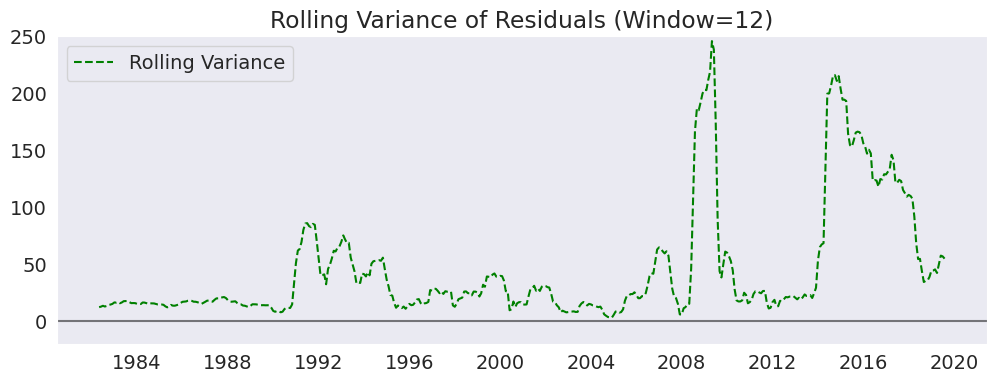

In [ ]:

# --- Rolling Mean/Variance for nomal data ---
window = 12

rolling_mean = residuals.rolling(window=window).mean()
rolling_var = residuals.rolling(window=window).var()

rolling_mean = rolling_mean.dropna()

rolling_var = rolling_var.dropna()

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()


# Plot Rolling Mean
plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of Residuals (Window=12)')
plt.ylim(-20, 40)
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Variance
plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Residuals (Window=12)')
plt.ylim(-20, 250)
plt.legend()
plt.grid()
plt.show()


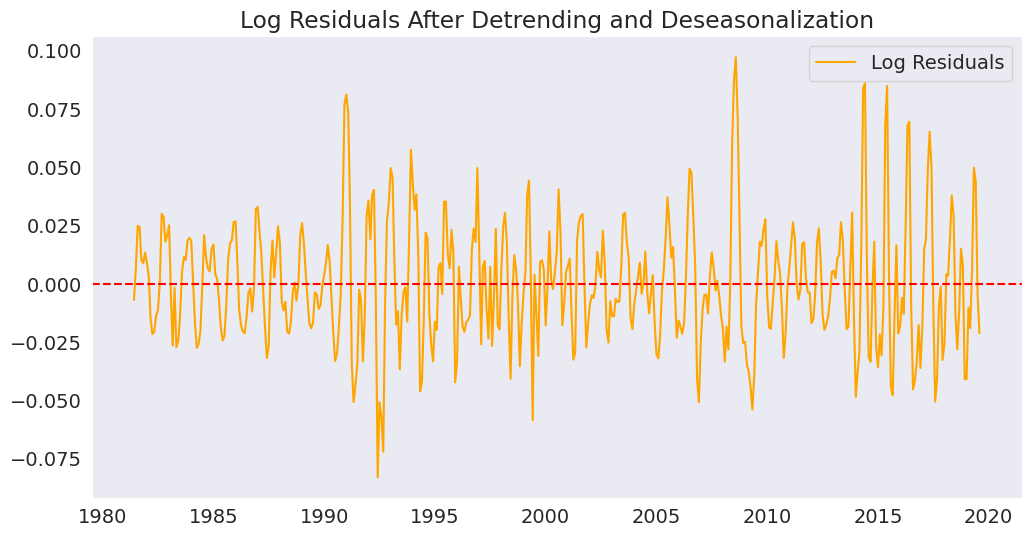

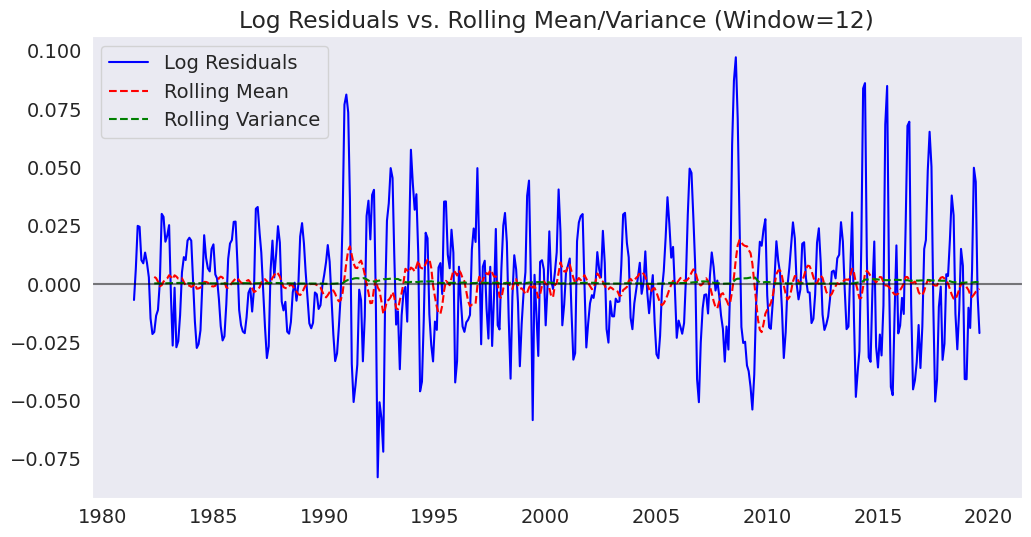

Index(['data', 'time_index', 'trend', 'detrended', 'seasonal', 'residual',
       'log_data', 'log_detrended', 'log_seasonal', 'log_residual'],
      dtype='object')


<Figure size 1200x400 with 0 Axes>

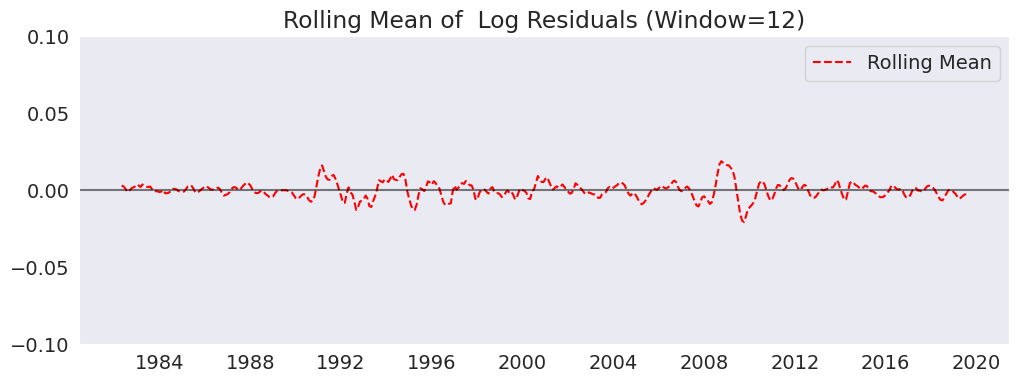

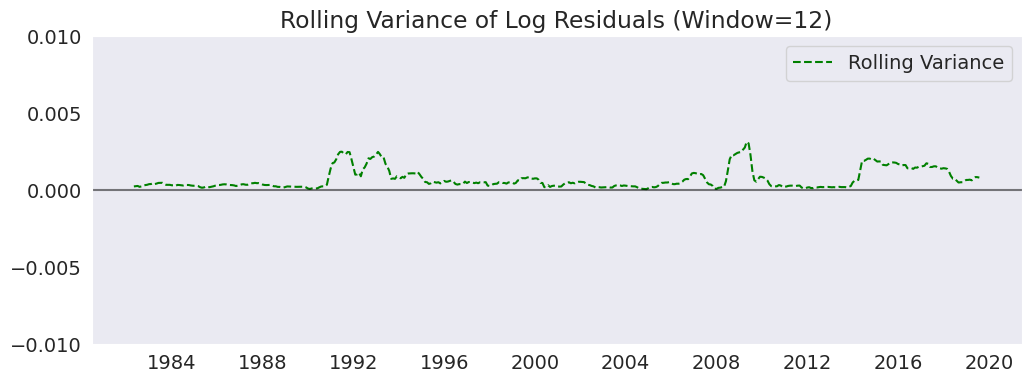

In [ ]:
# Rolloing mean and variance for Log normal data ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply Log Transformation to Stabilize Variance
df['log_data'] = np.log(df['data'])

# Re-calculate residuals after log transformation
time_index = (df.index.year - df.index.year.min()) * 12 + df.index.month
degree = 5  # Adjust this based on the optimal degree
coefficients = np.polyfit(time_index, df['log_data'], degree)
polynomial = np.poly1d(coefficients)
trend = polynomial(time_index)
df['log_detrended'] = df['log_data'] - trend

# Seasonal Decomposition on log-detrended data
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['log_detrended'].dropna(),
    model='additive',
    period=12
)

df['log_seasonal'] = decomposition.seasonal
df['log_residual'] = decomposition.resid

# Plot residuals after log transformation and detrending
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['log_residual'], label='Log Residuals', color='orange')
plt.axhline(0, color='r', linestyle='--')
plt.title('Log Residuals After Detrending and Deseasonalization')
plt.legend()
plt.grid()
plt.show()

# --- Rolling Mean/Variance for Log Residuals ---
window = 12  # Annual window for monthly data
rolling_mean = df['log_residual'].rolling(window=window).mean()
rolling_var = df['log_residual'].rolling(window=window).var()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['log_residual'], label='Log Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Log Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()
print(df.columns)

# Plot Rolling Mean
plt.figure(figsize=(12, 4))

# Plot Rolling Mean
plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of  Log Residuals (Window=12)')
plt.ylim(-0.1, 0.1)
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Variance
plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Log Residuals (Window=12)')
plt.ylim(-0.01, 0.01)
plt.legend()
plt.grid()
plt.show()


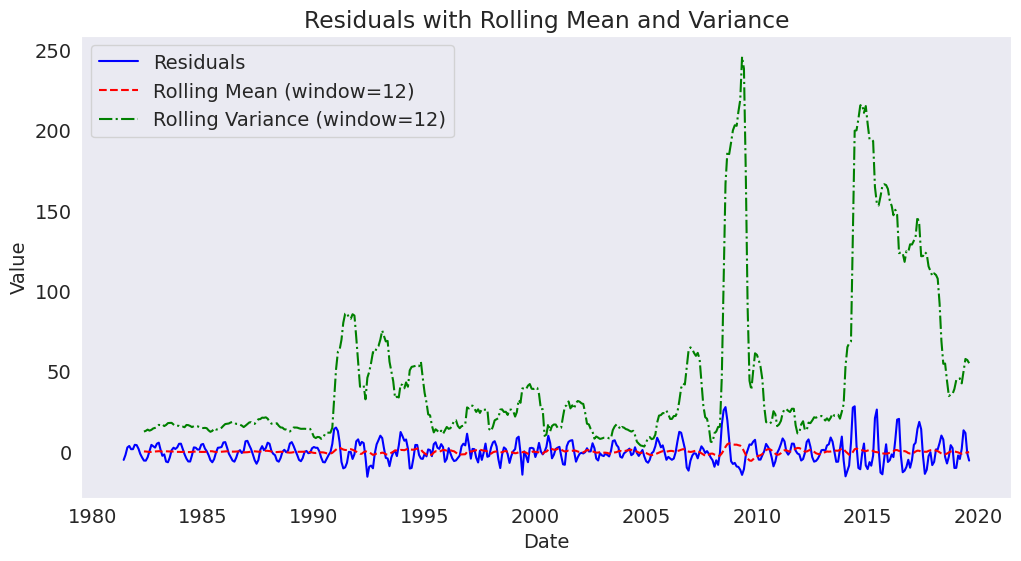

Identified Outliers in Residuals:
             residual
year_month           
2008-07-01  25.716600
2008-08-01  27.761186
2014-05-01  27.434936
2014-06-01  28.253444
2015-05-01  20.865936
2015-06-01  26.226652
2016-05-01  19.964602
2016-06-01  20.426694


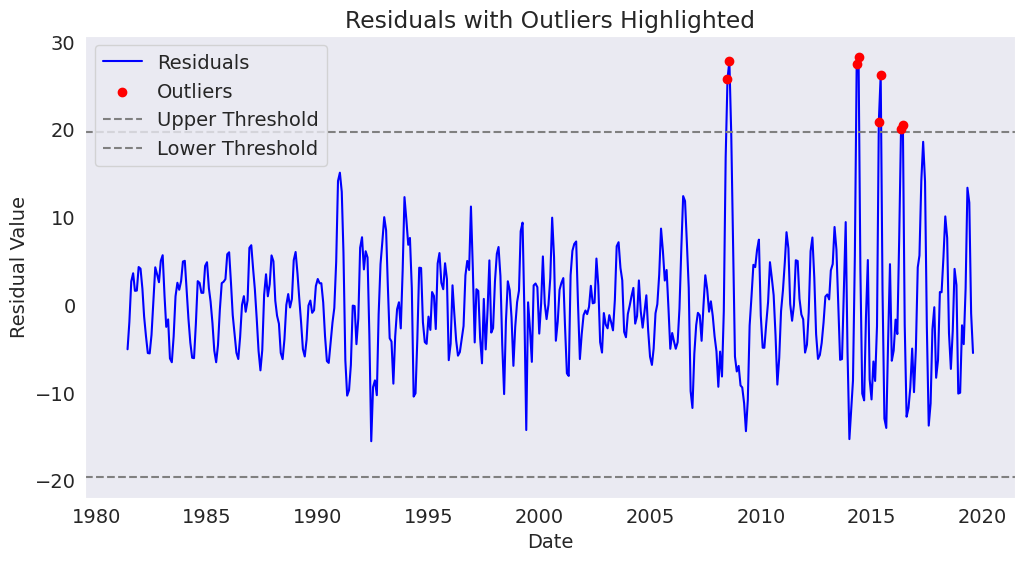

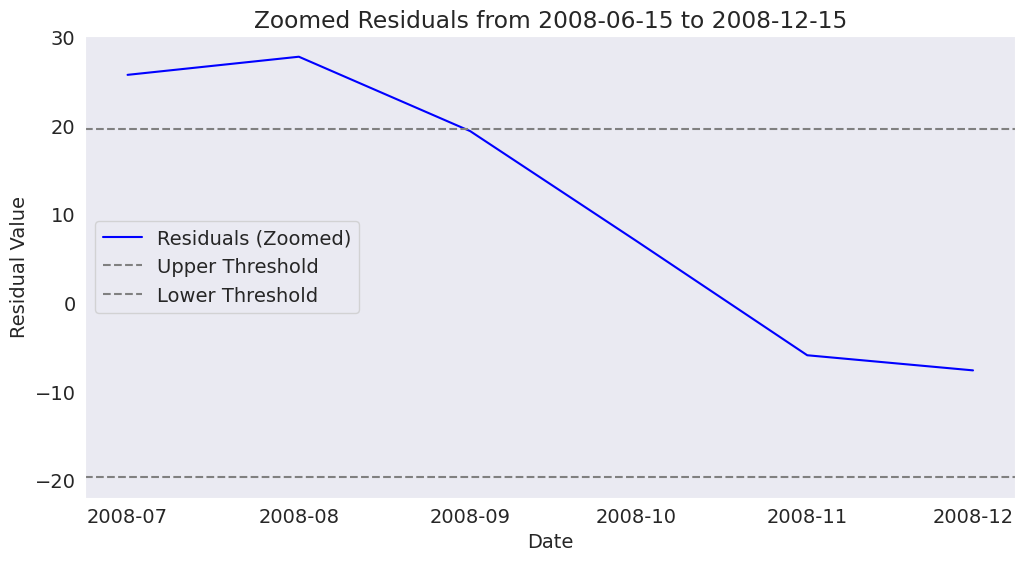

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For demonstration, let's assume df already exists with 'residual'
# If not, make sure you run your detrending/deseasonalizing code before this

# ---------------------------
# 1. Compute Rolling Statistics
# ---------------------------

# Choose a window size (e.g., 12 months for monthly data)
window_size = 12

# Calculate rolling mean and rolling variance for the residuals
df['rolling_mean'] = df['residual'].rolling(window=window_size).mean()
df['rolling_var'] = df['residual'].rolling(window=window_size).var()

# Plot the residuals with rolling mean and variance
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['residual'], label='Residuals', color='blue')
plt.plot(df.index, df['rolling_mean'], label=f'Rolling Mean (window={window_size})', color='red', linestyle='--')
plt.plot(df.index, df['rolling_var'], label=f'Rolling Variance (window={window_size})', color='green', linestyle='-.')
plt.title('Residuals with Rolling Mean and Variance')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 2. Identify Outliers in Residuals
# ---------------------------

# Compute overall mean and standard deviation of the residuals (ignoring NaNs)
resid_mean = df['residual'].mean()
resid_std = df['residual'].std()

# Define thresholds for outlier detection (e.g., beyond ±3 standard deviations)
upper_threshold = resid_mean + 3 * resid_std
lower_threshold = resid_mean - 3 * resid_std

# Create a boolean column 'outlier' where True indicates an outlier
df['outlier'] = (df['residual'] > upper_threshold) | (df['residual'] < lower_threshold)

# Print the dates and residual values identified as outliers
outliers = df[df['outlier']]
print("Identified Outliers in Residuals:")
print(outliers[['residual']])

# Plot residuals and highlight the outliers
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['residual'], label='Residuals', color='blue')
plt.scatter(outliers.index, outliers['residual'], color='red', label='Outliers', zorder=5)
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title('Residuals with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 3. Zoom In on Specific Time Period for Detailed Analysis
# ---------------------------

# Specify the time period you want to zoom in on.
# For example, to investigate a spike around 2016:
zoom_start = '2008-06-15'
zoom_end = '2008-12-15'

# Subset the DataFrame for the specified time range
df_zoom = df.loc[zoom_start:zoom_end]

# Plot the zoomed residuals with the threshold lines
plt.figure(figsize=(12, 6))
plt.plot(df_zoom.index, df_zoom['residual'], label='Residuals (Zoomed)', color='blue')
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title(f'Zoomed Residuals from {zoom_start} to {zoom_end}')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()


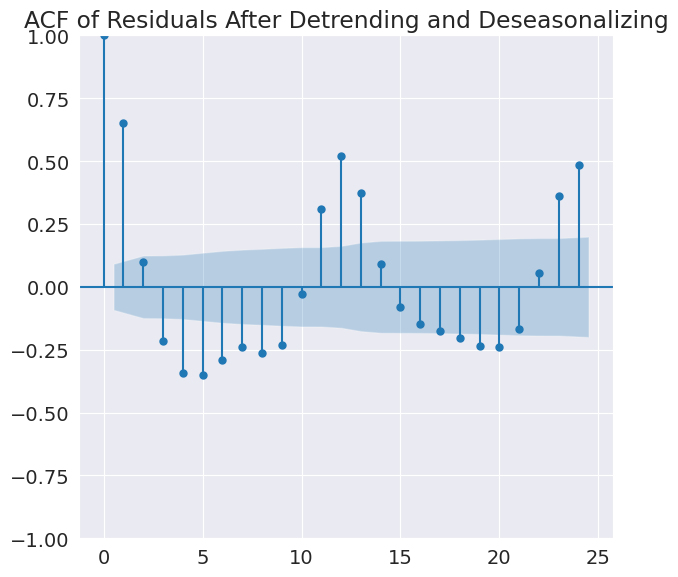

In [ ]:
#ACF and PACF for log residual data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(df['residual'].dropna(), lags=24, ax=plt.gca())
plt.title('ACF of Residuals After Detrending and Deseasonalizing')

# plt.subplot(1, 2, 2)
# plot_pacf(df['residual'].dropna(), lags=24, ax=plt.gca())
# plt.title('PACF of Residuals After Detrending and Deseasonalizing')

plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               data   No. Observations:                  471
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -1282.237
Date:                            Mon, 07 Apr 2025   AIC                           2574.474
Time:                                    11:37:55   BIC                           2594.964
Sample:                                12-01-1980   HQIC                          2582.554
                                     - 02-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9409      0.014     67.567      0.000       0.914       0.968
ma.L1          0.5845      0.030   

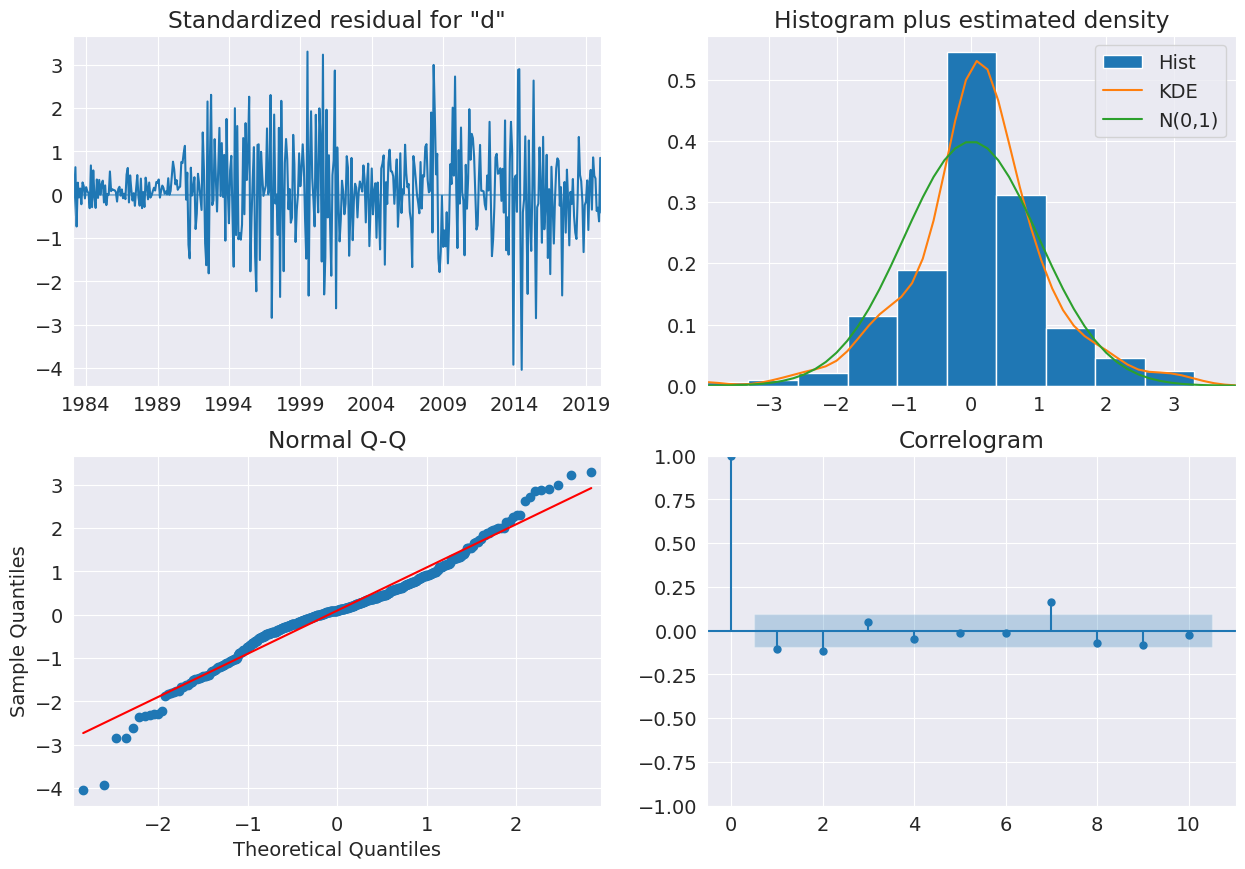

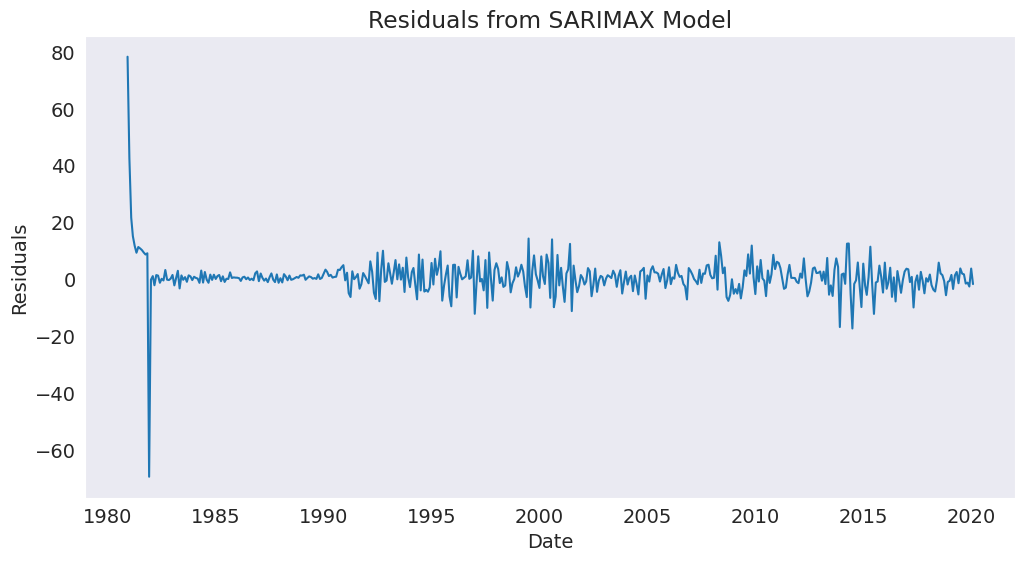

<Figure size 1200x600 with 0 Axes>

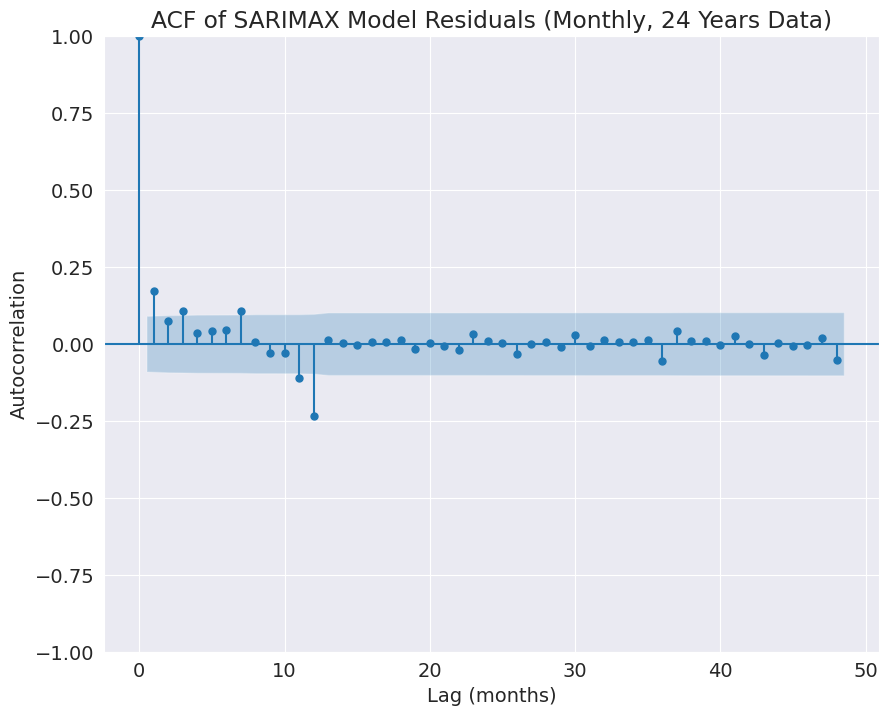

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# Assuming your DataFrame 'df' is already loaded, indexed by date, and has a 'data' column.
# If you want to model the original series, use df['data'].
# Alternatively, if you want to model the residuals after detrending/deseasonalizing, use df['residual'].
# Here, we demonstrate modeling the original series.

# ---------------------------
# 1. Fit a SARIMAX Model
# ---------------------------
# For monthly data with 24 years (~288 observations), a seasonal order is crucial.
# We choose seasonal_order=(P, D, Q, s) with s=12 for a yearly seasonality.
# The orders (p,d,q) and (P,D,Q) below are examples. You may need to adjust them after diagnosis.
model = SARIMAX(df['data'],
                order=(1, 0, 1),             # Non-seasonal ARIMA order (p, d, q)
                seasonal_order=(1, 1, 1, 12),  # Seasonal order (P, D, Q, s) with s=12
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# ---------------------------
# 2. Diagnostic Plots
# ---------------------------
# Check model diagnostics to see if residuals look like white noise.
model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# ---------------------------
# 3. Check Residuals and Their ACF
# ---------------------------
# Extract model residuals and plot them
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals from SARIMAX Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid()
plt.show()

# Plot ACF of the residuals to see if there is any remaining autocorrelation
plt.figure(figsize=(12, 6))
plot_acf(residuals, lags=48, alpha=0.05)
plt.title('ACF of SARIMAX Model Residuals (Monthly, 24 Years Data)')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.show()


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import plotly.express as px
from wordcloud import WordCloud
from collections import Counter
from typing import List
import matplotlib.gridspec as gridspec
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize'] = (10,8)
pd.set_option('display.max_columns', None)


file_path = '/content/gdrive/MyDrive/US_kerosene_filtered.xlsx'

df2 = pd.read_excel(file_path)
df2['date'] = pd.to_datetime(df2['date'], format='%Y %b', errors='coerce')


df2.to_csv("cleaned_file.csv", index=False)

df2.head()

,year_month,date,data
0,2005-01,2005-01-03,2.23
1,2005-02,2005-02-07,2.29
2,2005-03,2005-03-07,2.34
3,2005-04,2005-04-11,2.45
4,2005-05,2005-05-16,2.34


Mean: 3.79
Variance: 0.93


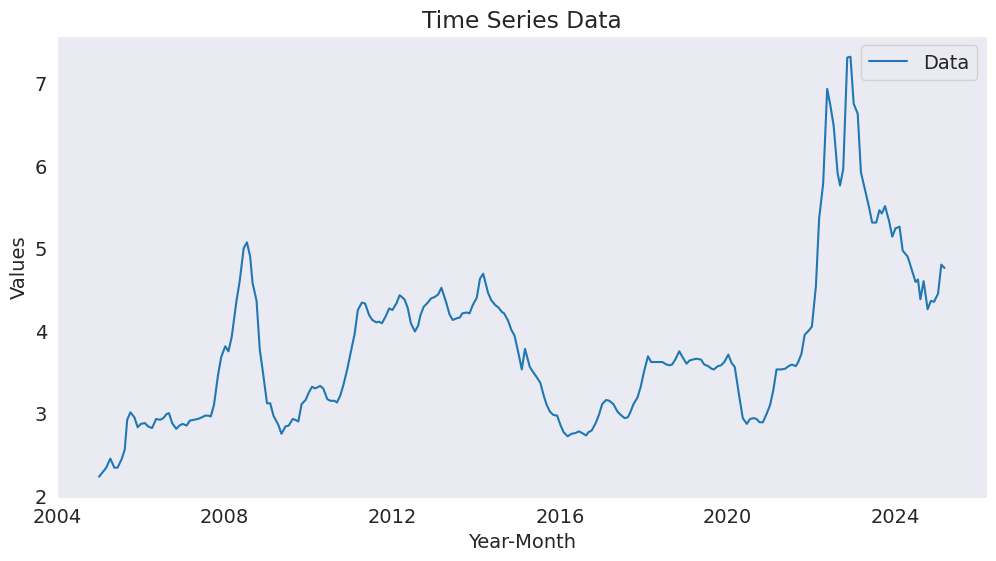

In [ ]:
#Printing the data for the Years
import pandas as pd
import matplotlib.pyplot as plt


df2 = pd.read_csv("cleaned_file.csv", parse_dates=['date'])

df2.set_index('date', inplace=True)

mean_value = df2['data'].mean()
variance_value = df2['data'].var()

print(f"Mean: {mean_value:.2f}")

print(f"Variance: {variance_value:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['data'], label='Data')
plt.xlabel("Year-Month")
plt.ylabel("Values")
plt.title("Time Series Data")
plt.legend()
plt.grid()
plt.show()


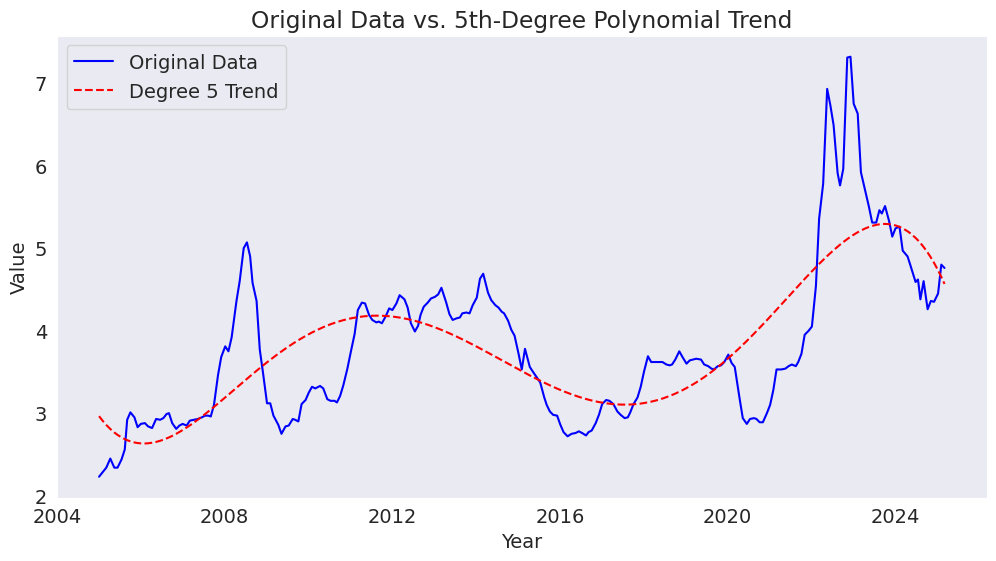

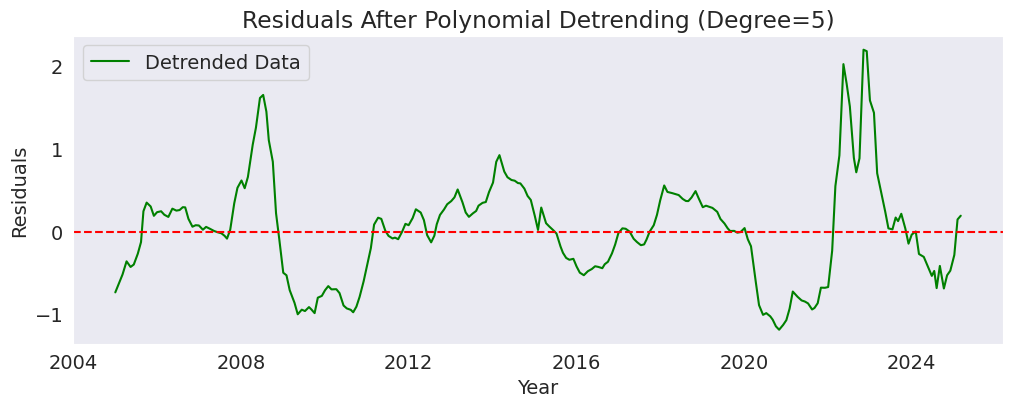

Error in decomposition: Multiplicative seasonality is not appropriate for zero and negative values


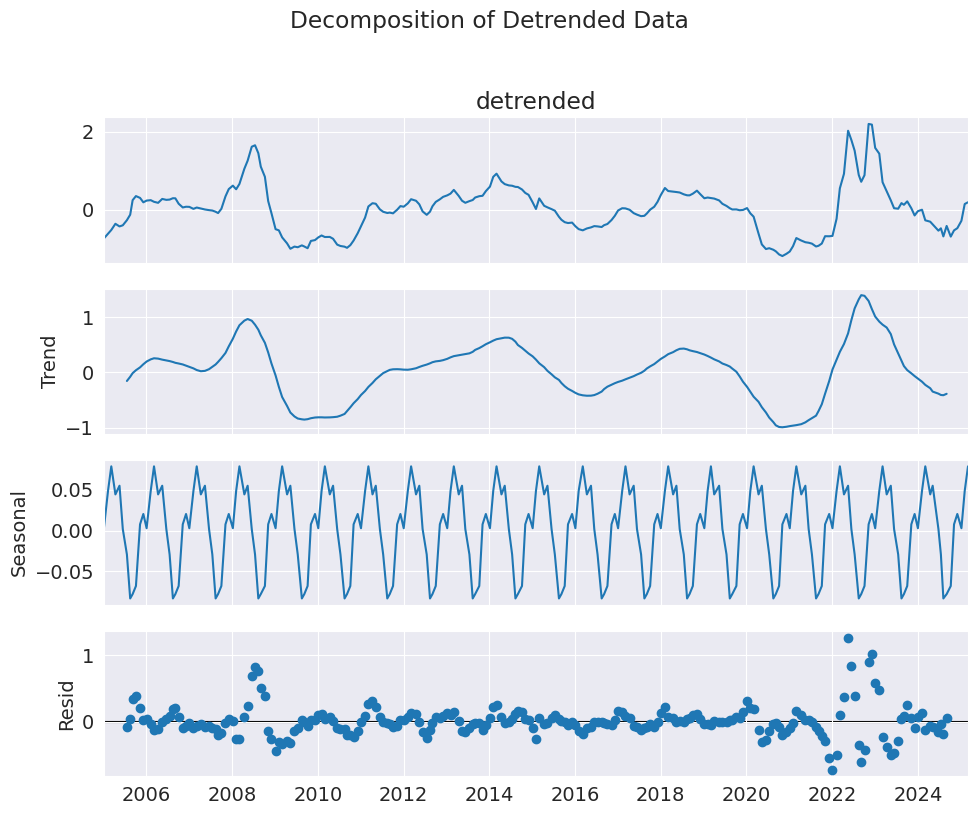

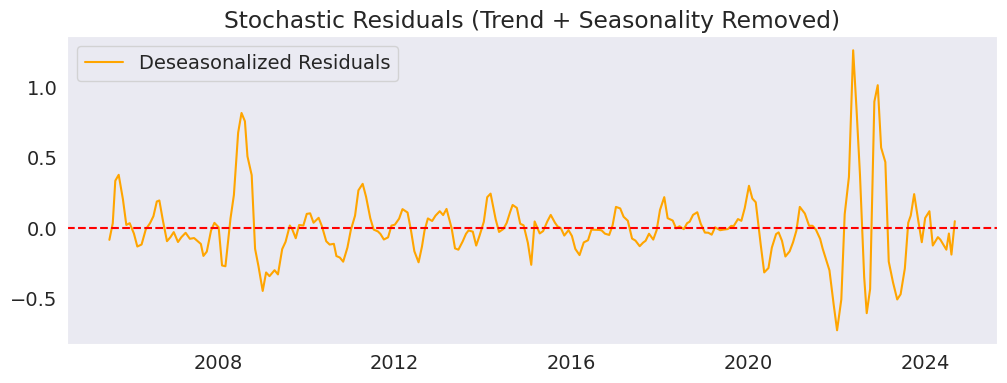

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load data
df2 = pd.read_csv("cleaned_file.csv", parse_dates=['date'])
df2.set_index('date', inplace=True)
df2 = df2.sort_index()


df2['time_index'] = (df2.index - df2.index.min()).days / 30.44

degree = 5
coefficients = np.polyfit(df2['time_index'], df2['data'], degree)
polynomial = np.poly1d(coefficients)
df2['trend'] = polynomial(df2['time_index'])


df2['detrended'] = df2['data'] - df2['trend']


plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['data'], label='Original Data', color='blue')
plt.plot(df2.index, df2['trend'], label=f'Degree {degree} Trend', linestyle='--', color='red')
plt.title(f'Original Data vs. {degree}th-Degree Polynomial Trend')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['detrended'], label='Detrended Data', color='green')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Residuals After Polynomial Detrending (Degree={degree})')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()

try:
    decomposition_add = seasonal_decompose(df2['detrended'].dropna(), model='additive', period=100)
    decomposition_mult = seasonal_decompose(df2['detrended'].dropna(), model='multiplicative', period=100)

    var_add = np.nanvar(decomposition_add.resid)
    var_mult = np.nanvar(decomposition_mult.resid)

    if var_mult < var_add:
        decomposition = decomposition_mult
        print("Using Multiplicative Decomposition (Lower Residual Variance)")
    else:
        decomposition = decomposition_add
        print("Using Additive Decomposition (Lower Residual Variance)")
except Exception as e:
    print("Error in decomposition:", e)
    decomposition = seasonal_decompose(df2['detrended'].dropna(), model='additive', period=12)


df2['seasonal'] = decomposition.seasonal
df2['poly_residual'] = decomposition.resid.dropna()

decomposition.plot()
plt.suptitle('Decomposition of Detrended Data', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['poly_residual'], label='Deseasonalized Residuals', color='orange')
plt.axhline(0, color='r', linestyle='--')
plt.title('Stochastic Residuals (Trend + Seasonality Removed)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Stationarity Check
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = df2['poly_residual'].dropna()


adf_result = adfuller(residuals)
print("ADF Test:")
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical Values: {adf_result[4]}")
print("Conclusion:", "Stationary" if adf_result[1] < 0.05 else "Non-Stationary")


kpss_result = kpss(residuals, regression='c')
print("\nKPSS Test:")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Critical Values: {kpss_result[3]}")
print("Conclusion:", "Non-Stationary" if kpss_result[1] < 0.05 else "Stationary")


ADF Test:
  Test Statistic: -6.1774
  p-value: 0.0000
  Critical Values: {'1%': np.float64(-3.460567372610299), '5%': np.float64(-2.874829809033386), '10%': np.float64(-2.573853225954421)}
Conclusion: Stationary

KPSS Test:
  Test Statistic: 0.0208
  p-value: 0.1000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: Stationary


<ipython-input-14-93e6b9f9bce2>:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(residuals, regression='c')


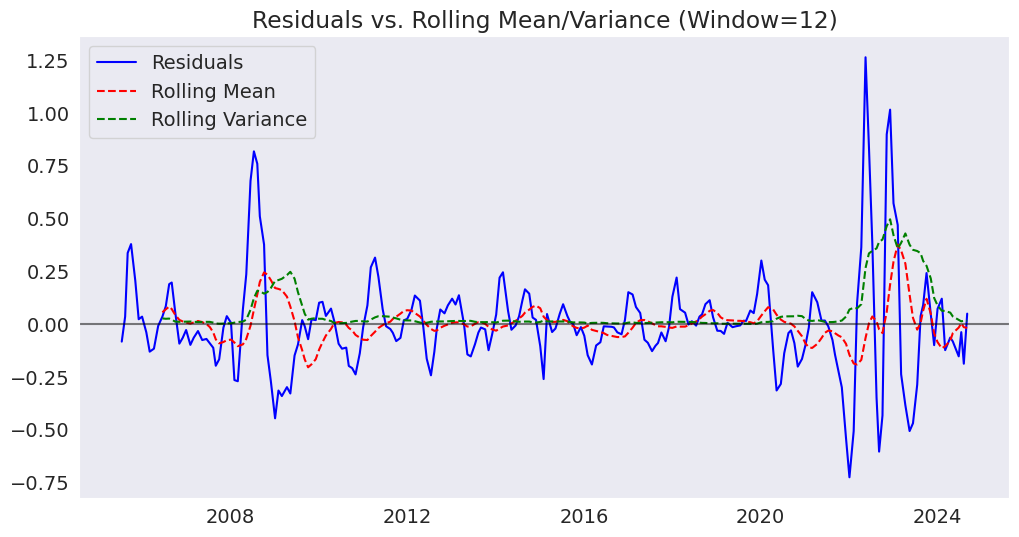

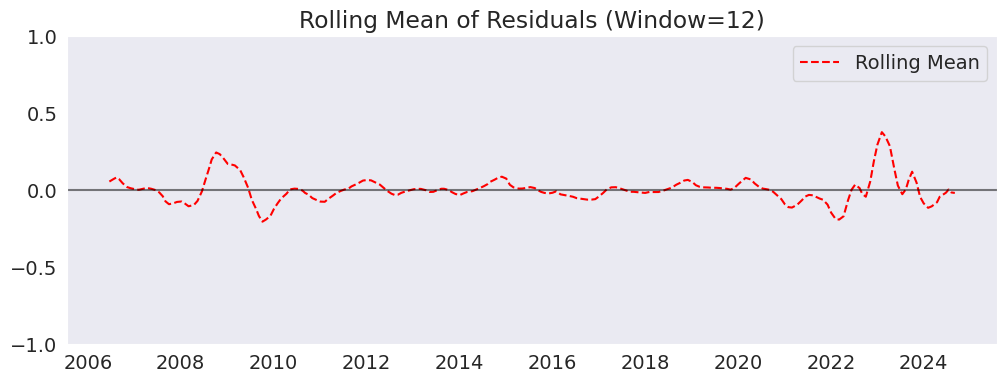

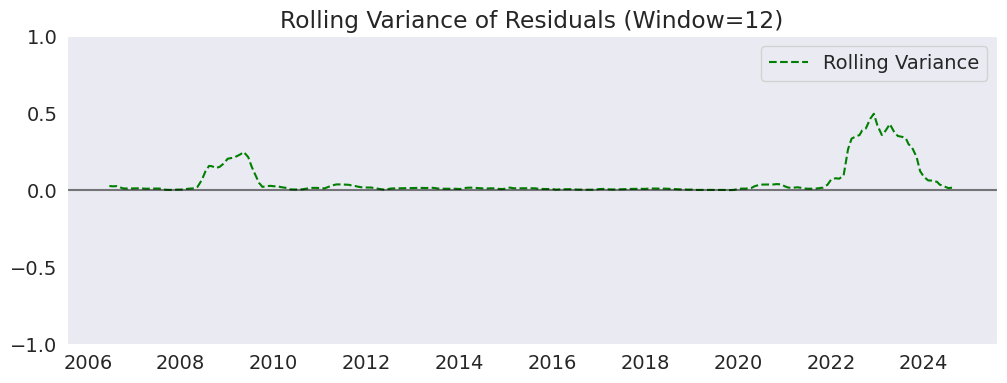

In [ ]:
# --- Rolling Mean/Variance for nomal data ---
window = 12

rolling_mean = residuals.rolling(window=window).mean()
rolling_var = residuals.rolling(window=window).var()


rolling_mean = rolling_mean.dropna()
rolling_var = rolling_var.dropna()


plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()


# Plot Rolling Mean
plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of Residuals (Window=12)')
plt.ylim(-1, 1)
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Variance
plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Residuals (Window=12)')
plt.ylim(-1, 1)
plt.legend()
plt.grid()
plt.show()



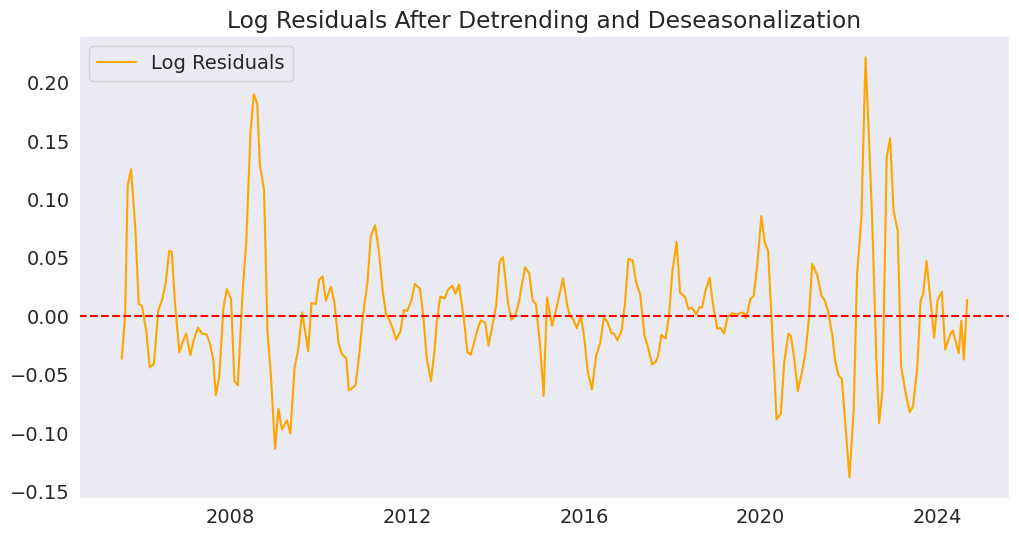

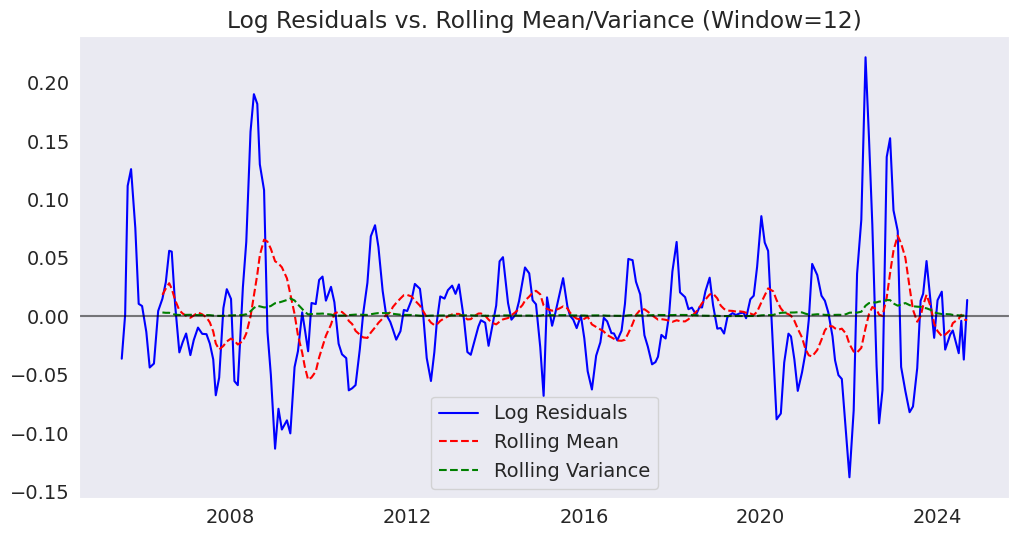

Index(['year_month', 'data', 'time_index', 'trend', 'detrended', 'seasonal',
       'poly_residual', 'log_data', 'log_detrended', 'log_seasonal',
       'log_residual'],
      dtype='object')


In [ ]:
# Rolloing mean and variance for Log normal data ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply Log Transformation to Stabilize Variance
df2['log_data'] = np.log(df2['data'])

# Re-calculate residuals after log transformation
time_index = (df2.index.year - df2.index.year.min()) * 12 + df2.index.month
degree = 5  # Adjust this based on the optimal degree
coefficients = np.polyfit(time_index, df2['log_data'], degree)
polynomial = np.poly1d(coefficients)
trend = polynomial(time_index)
df2['log_detrended'] = df2['log_data'] - trend

# Seasonal Decomposition on log-detrended data
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df2['log_detrended'].dropna(),
    model='additive',
    period=12
)

df2['log_seasonal'] = decomposition.seasonal
df2['log_residual'] = decomposition.resid

# Plot residuals after log transformation and detrending
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Log Residuals', color='orange')
plt.axhline(0, color='r', linestyle='--')
plt.title('Log Residuals After Detrending and Deseasonalization')
plt.legend()
plt.grid()
plt.show()

# --- Rolling Mean/Variance for Log Residuals ---
window = 12  # Annual window for monthly data
rolling_mean = df2['log_residual'].rolling(window=window).mean()
rolling_var = df2['log_residual'].rolling(window=window).var()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df2['log_residual'], label='Log Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Log Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()
print(df2.columns)

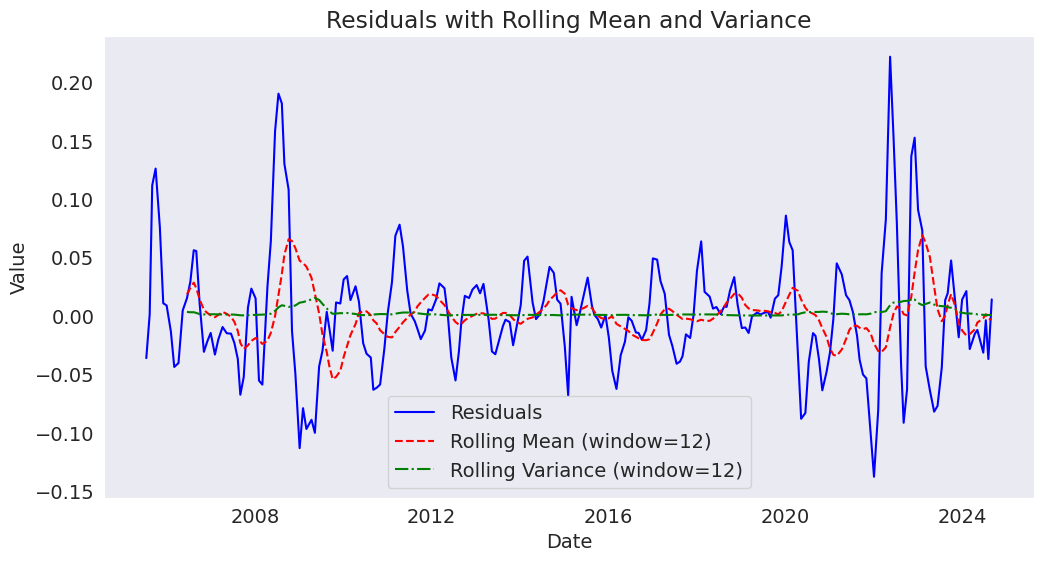

Identified Outliers in Residuals:
            log_residual
date                    
2008-06-16      0.157944
2008-07-14      0.190037
2008-08-11      0.181670
2022-05-16      0.221619


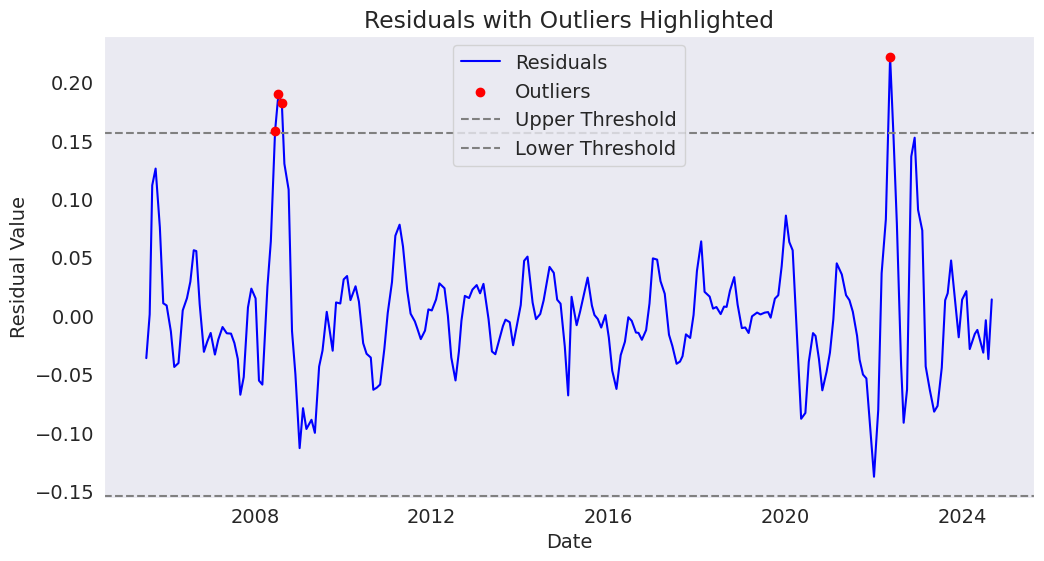

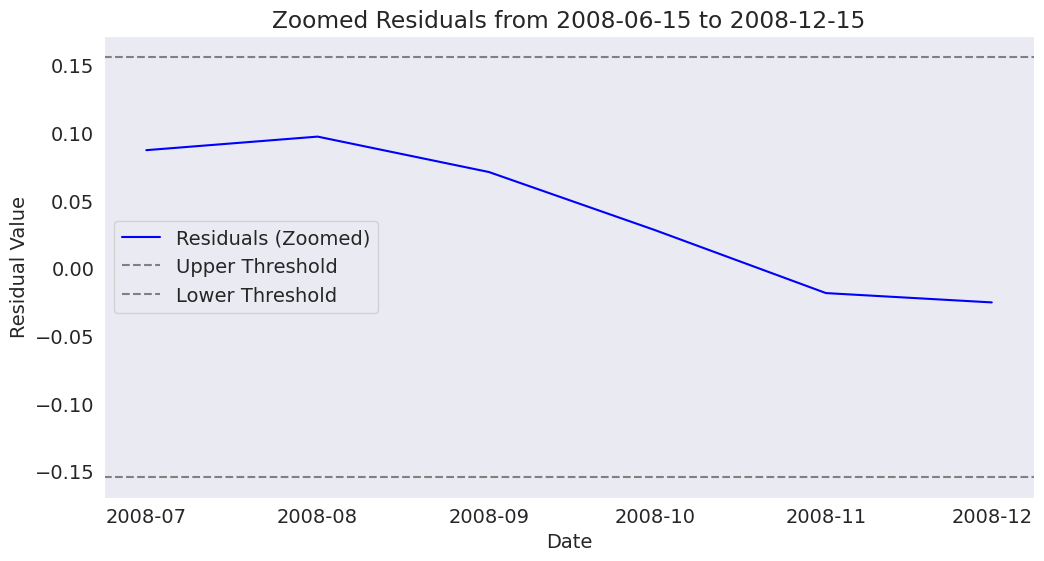

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For demonstration, let's assume df already exists with 'log_residual'
# If not, make sure you run your detrending/deseasonalizing code before this

# ---------------------------
# 1. Compute Rolling Statistics
# ---------------------------

# Choose a window size (e.g., 12 months for monthly data)
window_size = 12

# Calculate rolling mean and rolling variance for the residuals
df2['rolling_mean'] = df2['log_residual'].rolling(window=window_size).mean()
df2['rolling_var'] = df2['log_residual'].rolling(window=window_size).var()

# Plot the residuals with rolling mean and variance
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Residuals', color='blue')
plt.plot(df2.index, df2['rolling_mean'], label=f'Rolling Mean (window={window_size})', color='red', linestyle='--')
plt.plot(df2.index, df2['rolling_var'], label=f'Rolling Variance (window={window_size})', color='green', linestyle='-.')
plt.title('Residuals with Rolling Mean and Variance')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 2. Identify Outliers in Residuals
# ---------------------------

# Compute overall mean and standard deviation of the residuals (ignoring NaNs)
resid_mean = df2['log_residual'].mean()
resid_std = df2['log_residual'].std()

# Define thresholds for outlier detection (e.g., beyond ±3 standard deviations)
upper_threshold = resid_mean + 3 * resid_std
lower_threshold = resid_mean - 3 * resid_std

# Create a boolean column 'outlier' where True indicates an outlier
df2['outlier'] = (df2['log_residual'] > upper_threshold) | (df2['log_residual'] < lower_threshold)

# Print the dates and residual values identified as outliers
outliers = df2[df2['outlier']]
print("Identified Outliers in Residuals:")
print(outliers[['log_residual']])

# Plot residuals and highlight the outliers
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Residuals', color='blue')
plt.scatter(outliers.index, outliers['log_residual'], color='red', label='Outliers', zorder=5)
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title('Residuals with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 3. Zoom In on Specific Time Period for Detailed Analysis
# ---------------------------

# Specify the time period you want to zoom in on.
# For example, to investigate a spike around 2016:
zoom_start = '2008-06-15'
zoom_end = '2008-12-15'

# Subset the DataFrame for the specified time range
df_zoom = df.loc[zoom_start:zoom_end]

# Plot the zoomed residuals with the threshold lines
plt.figure(figsize=(12, 6))
plt.plot(df_zoom.index, df_zoom['log_residual'], label='Residuals (Zoomed)', color='blue')
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title(f'Zoomed Residuals from {zoom_start} to {zoom_end}')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()


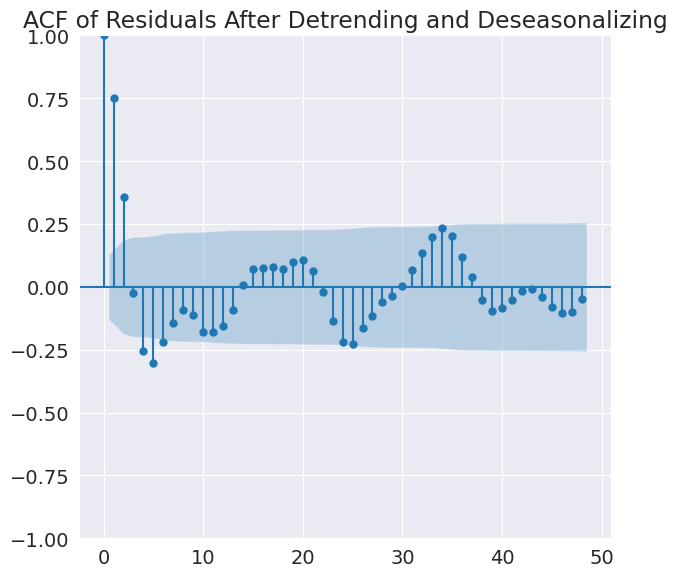

In [ ]:
#ACF and PACF for log residual data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(df2['log_residual'].dropna(), lags=48, ax=plt.gca())
plt.title('ACF of Residuals After Detrending and Deseasonalizing')

# plt.subplot(1, 2, 2)
# plot_pacf(df2['log_residual'].dropna(), lags=24, ax=plt.gca())
# plt.title('PACF of Residuals After Detrending and Deseasonalizing')

plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               data   No. Observations:                  243
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                  36.667
Date:                            Mon, 07 Apr 2025   AIC                            -63.334
Time:                                    11:38:37   BIC                            -46.434
Sample:                                         0   HQIC                           -56.507
                                            - 243                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9682      0.014     71.158      0.000       0.942       0.995
ma.L1          0.3207      0.053   

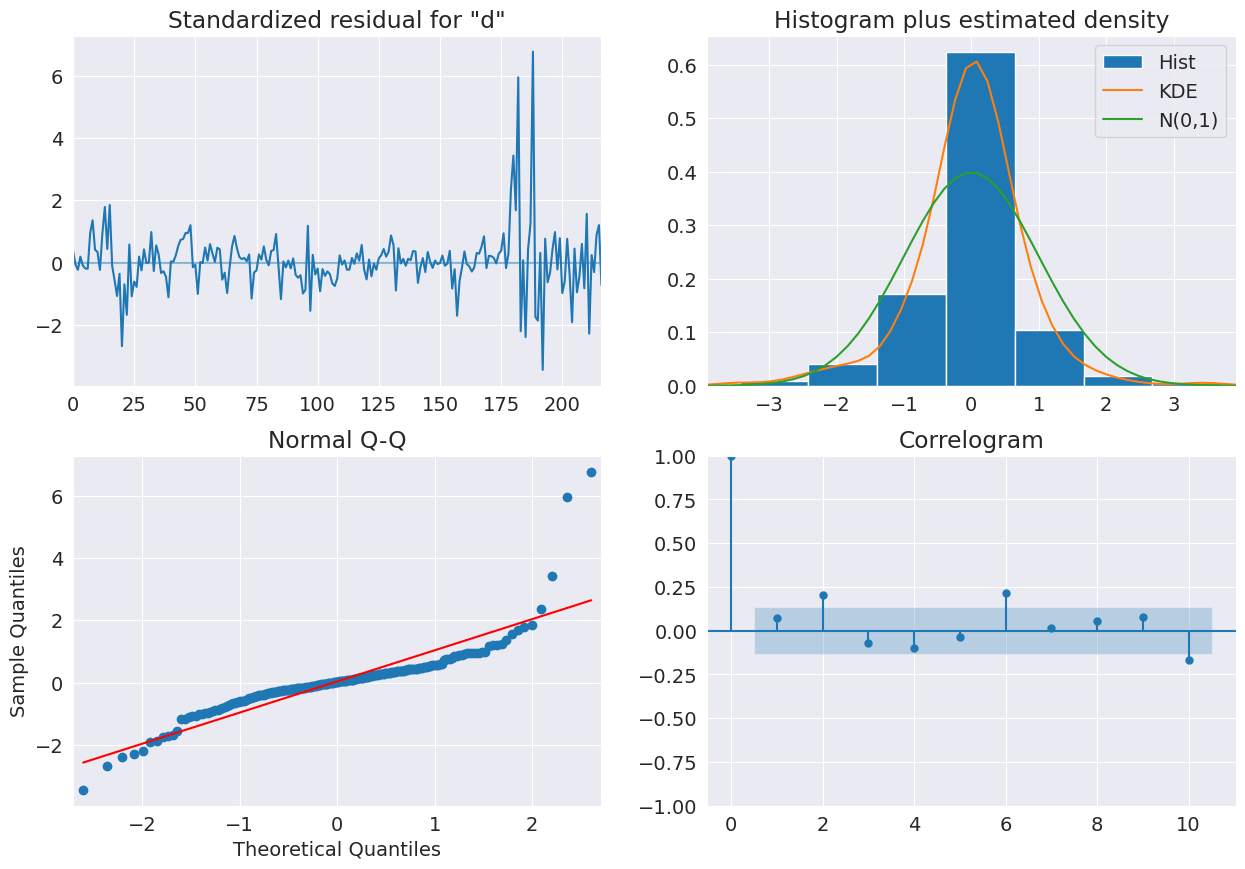

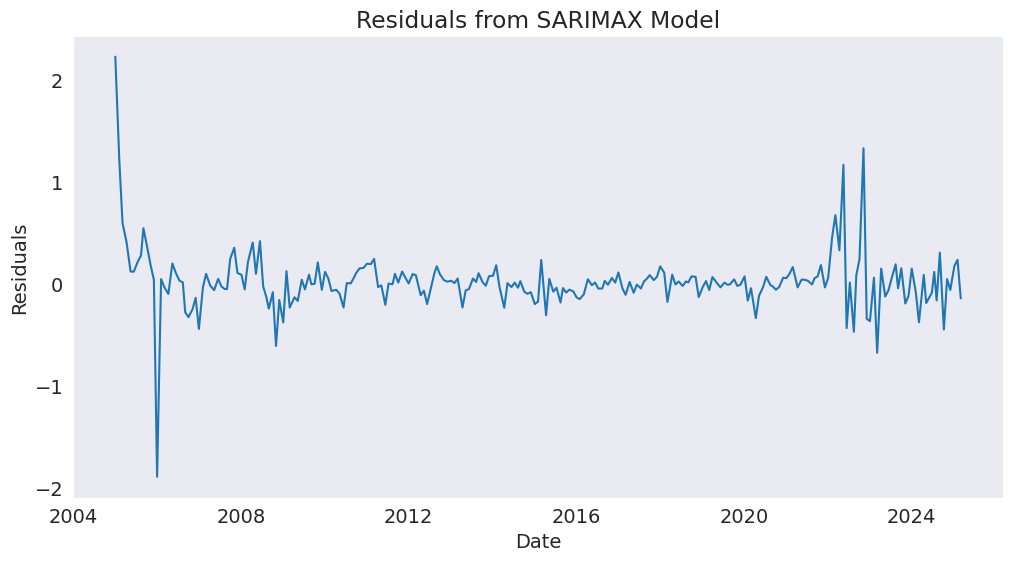

<Figure size 1200x600 with 0 Axes>

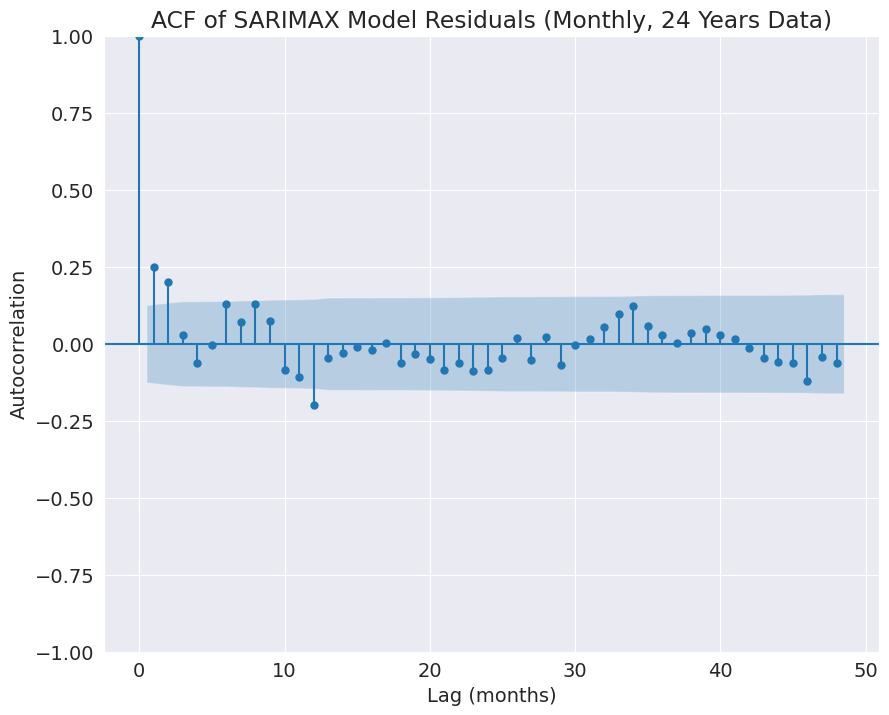

In [ ]:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  from statsmodels.tsa.statespace.sarimax import SARIMAX
  from statsmodels.graphics.tsaplots import plot_acf
  import statsmodels.api as sm

  # Assuming your DataFrame 'df2' is already loaded, indexed by date, and has a 'data' column.
  # If you want to model the original series, use df2['data'].
  # Alternatively, if you want to model the residuals after detrending/deseasonalizing, use df2['residual'].
  # Here, we demonstrate modeling the original series.

  # ---------------------------
  # 1. Fit a SARIMAX Model
  # ---------------------------
  # For monthly data with 24 years (~288 observations), a seasonal order is crucial.
  # We choose seasonal_order=(P, D, Q, s) with s=12 for a yearly seasonality.
  # The orders (p,d,q) and (P,D,Q) below are examples. You may need to adjust them after diagnosis.
  model = SARIMAX(df2['data'],
                  order=(1, 0, 1),             # Non-seasonal ARIMA order (p, d, q)
                  seasonal_order=(1, 1, 1, 12),  # Seasonal order (P, D, Q, s) with s=12
                  enforce_stationarity=False,
                  enforce_invertibility=False)

  model_fit = model.fit(disp=False)
  print(model_fit.summary())

  # ---------------------------
  # 2. Diagnostic Plots
  # ---------------------------
  # Check model diagnostics to see if residuals look like white noise.
  model_fit.plot_diagnostics(figsize=(15, 10))
  plt.show()

  # ---------------------------
  # 3. Check Residuals and Their ACF
  # ---------------------------
  # Extract model residuals and plot them
  residuals = model_fit.resid
  plt.figure(figsize=(12, 6))
  plt.plot(residuals)
  plt.title('Residuals from SARIMAX Model')
  plt.xlabel('Date')
  plt.ylabel('Residuals')
  plt.grid()
  plt.show()

  # Plot ACF of the residuals to see if there is any remaining autocorrelation
  plt.figure(figsize=(12, 6))
  plot_acf(residuals, lags=48, alpha=0.05)
  plt.title('ACF of SARIMAX Model Residuals (Monthly, 24 Years Data)')
  plt.xlabel('Lag (months)')
  plt.ylabel('Autocorrelation')
  plt.show()



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               data   No. Observations:                  243
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                  36.667
Date:                            Mon, 07 Apr 2025   AIC                            -63.334
Time:                                    11:38:42   BIC                            -46.434
Sample:                                         0   HQIC                           -56.507
                                            - 243                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9682      0.014     71.158      0.000       0.942       0.995
ma.L1          0.3207      0.053   

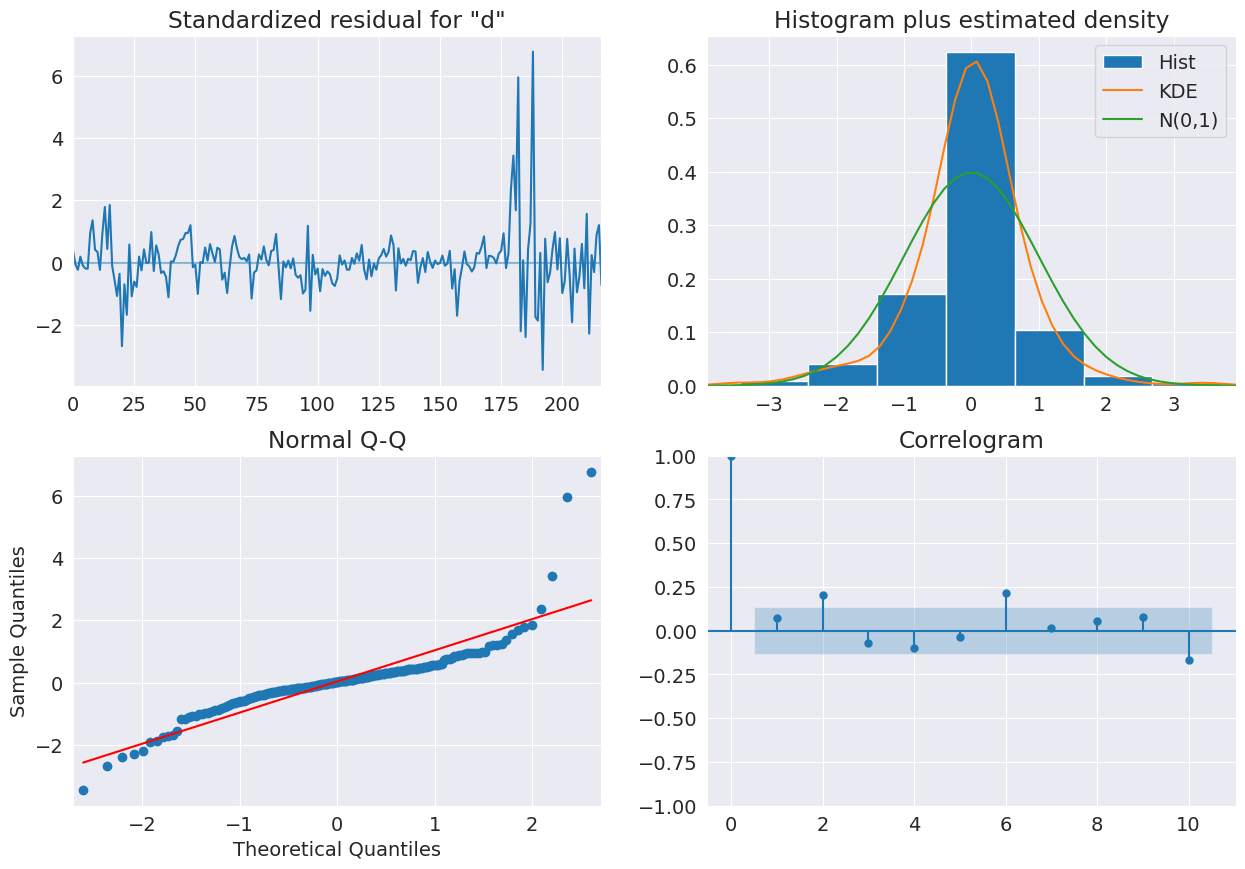

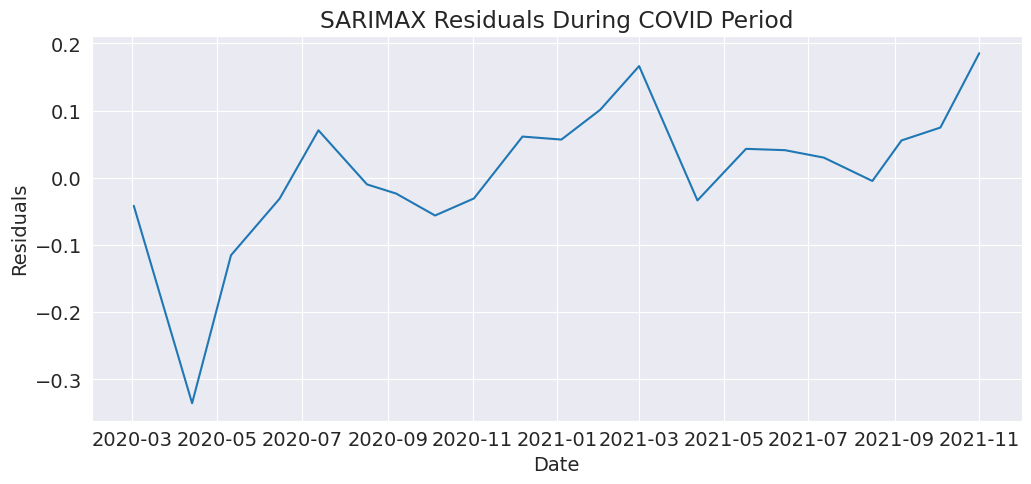

<Figure size 1200x500 with 0 Axes>

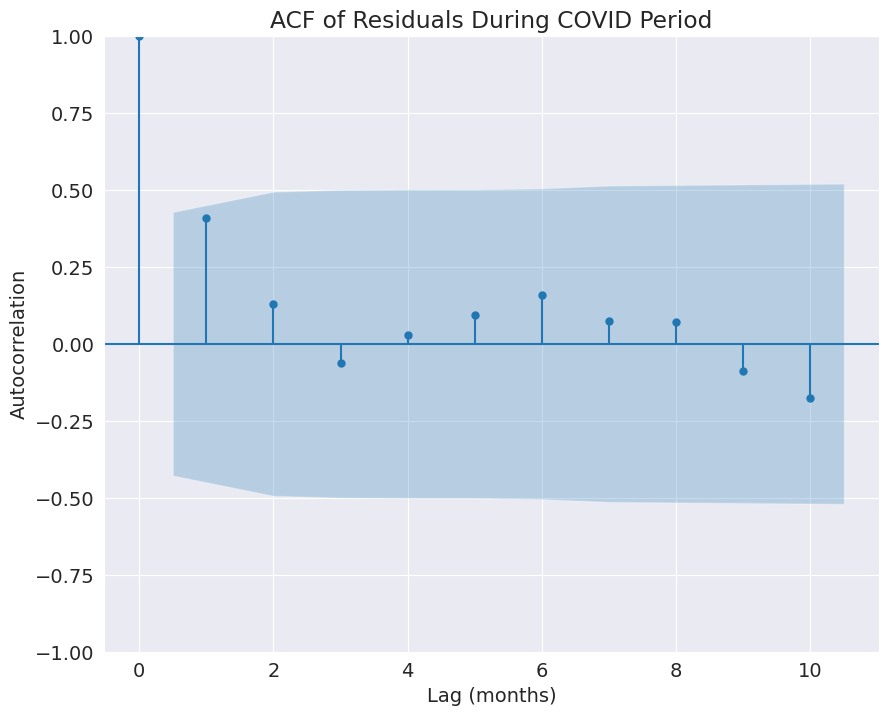

In [ ]:

  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  from statsmodels.tsa.statespace.sarimax import SARIMAX
  from statsmodels.graphics.tsaplots import plot_acf
  import statsmodels.api as sm

  # Assuming your DataFrame 'df2' is already loaded, indexed by date, and has a 'data' column.
  # If you want to model the original series, use df2['data'].
  # Alternatively, if you want to model the residuals after detrending/deseasonalizing, use df2['residual'].
  # Here, we demonstrate modeling the original series.

  # ---------------------------
  # 1. Fit a SARIMAX Model
  # ---------------------------
  # For monthly data with 24 years (~288 observations), a seasonal order is crucial.
  # We choose seasonal_order=(P, D, Q, s) with s=12 for a yearly seasonality.
  # The orders (p,d,q) and (P,D,Q) below are examples. You may need to adjust them after diagnosis.
  model = SARIMAX(df2['data'],
                  order=(1, 0, 1),             # Non-seasonal ARIMA order (p, d, q)
                  seasonal_order=(1, 1, 1, 12),  # Seasonal order (P, D, Q, s) with s=12
                  enforce_stationarity=False,
                  enforce_invertibility=False)

  model_fit = model.fit(disp=False)
  print(model_fit.summary())

  # ---------------------------
  # 2. Diagnostic Plots
  # ---------------------------
  # Check model diagnostics to see if residuals look like white noise.
  model_fit.plot_diagnostics(figsize=(15, 10))
  plt.show()
  # ---------------------------
# 3A. Filter Residuals for the COVID Period
# ---------------------------
# Adjust date range as per your definition of COVID period
covid_start = '2020-03-01'
covid_end = '2021-12-01'

# Filter residuals during the COVID period
residuals_covid = residuals.loc[covid_start:covid_end]

# Plot residuals during COVID
plt.figure(figsize=(12, 5))
plt.plot(residuals_covid)
plt.title('SARIMAX Residuals During COVID Period')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Plot ACF of residuals during COVID
plt.figure(figsize=(12, 5))
plot_acf(residuals_covid, lags=10, alpha=0.05)  # Use lags=10 or fewer
 # You can adjust lags (e.g., 24 months = 2 years)
plt.title('ACF of Residuals During COVID Period')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()


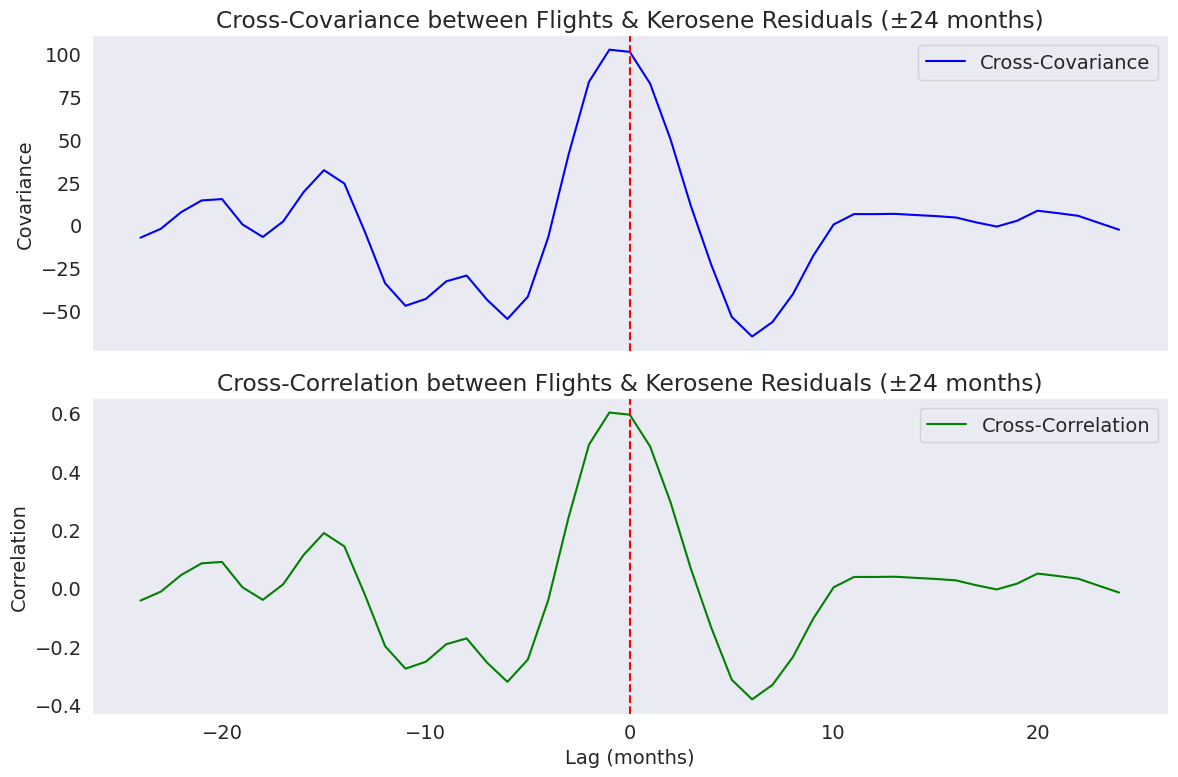

Pearson Correlation (lag = 0): 0.3989


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Step 1: Standardize the Index ---
df.index = pd.to_datetime(df.index)
df2.index = pd.to_datetime(df2.index)

df.index = df.index.to_period('M').to_timestamp()
df2.index = df2.index.to_period('M').to_timestamp()

# --- Step 2: Filter by Date Range ---
start_date = "2002-01-01"
end_date = "2020-12-31"

railway_residuals = df2['poly_residual'].loc[start_date:end_date]
diesel_residuals = df['residual'].loc[start_date:end_date]

# --- Step 3: Align and Drop NaNs ---
filtered_df = pd.DataFrame({
    'railway': railway_residuals,
    'diesel': diesel_residuals
}).dropna()

railway_residuals = filtered_df['railway']
diesel_residuals = filtered_df['diesel']

# --- Step 4: Cross-Covariance & Cross-Correlation ---
cross_cov = np.correlate(railway_residuals, diesel_residuals, mode='full')
lags_full = np.arange(-len(railway_residuals) + 1, len(railway_residuals))
cross_corr = cross_cov / len(railway_residuals)

# --- Step 5: Limit the Lag Range ---
lag_limit = 24  # months
center_idx = len(cross_corr) // 2
start_idx = center_idx - lag_limit
end_idx = center_idx + lag_limit + 1

lags = lags_full[start_idx:end_idx]
cross_cov_limited = cross_cov[start_idx:end_idx]
cross_corr_limited = cross_corr[start_idx:end_idx]

# --- Step 6: Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(lags, cross_cov_limited, label='Cross-Covariance', color='blue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title("Cross-Covariance between Flights & Kerosene Residuals (±24 months)")
ax[0].set_ylabel("Covariance")
ax[0].legend()
ax[0].grid()

ax[1].plot(lags, cross_corr_limited, label='Cross-Correlation', color='green')
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title("Cross-Correlation between Flights & Kerosene Residuals (±24 months)")
ax[1].set_xlabel("Lag (months)")
ax[1].set_ylabel("Correlation")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

# --- Step 7: Pearson Correlation at Lag 0 ---
pearson_corr, _ = pearsonr(railway_residuals, diesel_residuals)
print(f"Pearson Correlation (lag = 0): {pearson_corr:.4f}")
